In [1]:
import virtualreactor as vr
import numpy as np
from matplotlib import pyplot as plt

In [2]:
species = ["A", "B","C"]

stoichiometry = np.array([
    [-1],
    [ 2],
    [ 1]
])

pre_exponential_factors = np.array([
    1.0e3,
])

activation_energies = np.array([
    40_000.0,
])

reaction_enthalpies = np.array([
    -60_000.0,
])

reaction_entropies = np.array([
    -180.0,
])

reversible = np.array([
    True,
])

eq = vr.Mechanism(
    species=species,
    stoichiometry=stoichiometry,
    pre_exponential_factors=pre_exponential_factors,
    activation_energies=activation_energies,
    reaction_enthalpies=reaction_enthalpies,
    reaction_entropies=reaction_entropies,
    reversible=reversible,
)

batch_reactor=vr.BatchReactor()

constant_density_heat_capacity=vr.PropertyModel.constant(
        density=1000.0,
        heat_capacity=4180.0
        )

eq_sim=vr.Simulation(
    mechanism=eq,
    reactor=batch_reactor,
    properties=constant_density_heat_capacity
        )

In [11]:
temperature = 200.0

print("Stored entropy:")
print(eq.reaction_entropies)

print("Delta G:")
print(eq.reaction_gibbs_energies(temperature))

print("K:")
print(eq.equilibrium_constants(temperature))

kf, kr = eq.rate_constants(temperature)

print("kf:")
print(kf)

print("kr:")
print(kr)

Stored entropy:
[-180.]
Delta G:
[-24000.]
K:
[1853678.5077261]
kf:
[3.57499942e-08]
kr:
[1.92859733e-14]


In [19]:
eq_sim_result=eq_sim.solve(
    initial_state=np.array([
            1,0,0,300,0
        ]),
    xi_span=(
        0,50000
        )
    )

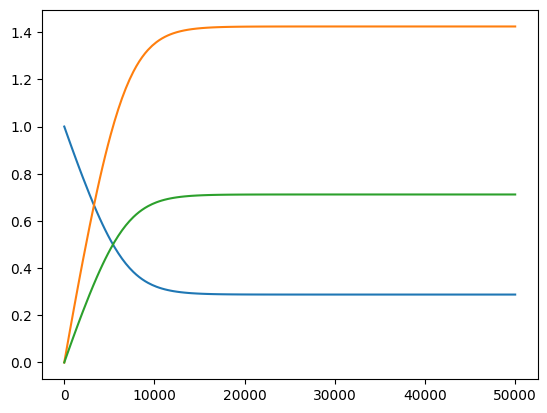

In [20]:
t=eq_sim_result['t']
c=eq_sim_result['y']
for i in range(3):
    plt.plot(t,c[i])

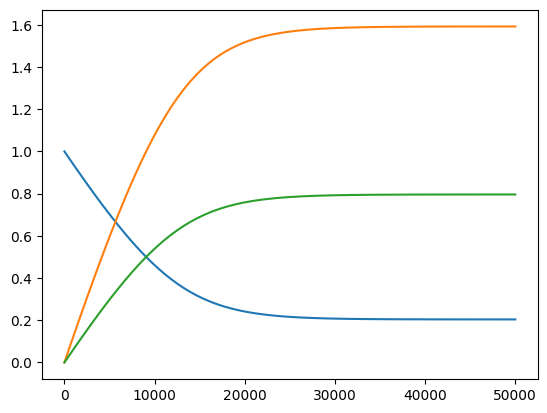

In [18]:
t=eq_sim_result['t']
c=eq_sim_result['y']
for i in range(3):
    plt.plot(t,c[i])

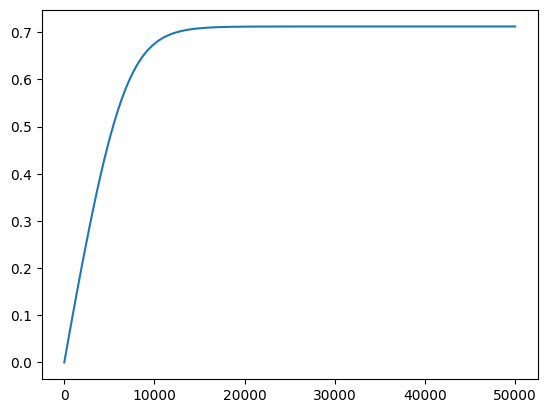

In [14]:
plt.plot(t,c[2])